# Type B — Funded-Continuation Recovery Hedge

**Hedge Type:** Hedge through the challenge, get funded, and **keep hedging at funded**.

**Method split (same as Type A):**
- **Static DD → Cross-firm pair:** 2 fees at different firms, accounts hedge each other at funded.
  Revenue = floor(DD% / target%) payouts per pair. Each pair costs 2 x challenge_cost.
  No personal drag. Costs are sunk if both accounts die before enough payouts.
- **Trailing DD → Personal hedge through funded:** Compounding continues. If funded fails,
  the hedge recovers the full cost stack (challenge + funded drag). Costs are recoverable.

## EV Formula

**Static DD (cross-firm pair, multi-payout):**
$$\text{EV}_B = \lfloor DD\% / target\% \rfloor \times S \times target\% \times split - 2 \times \text{challenge cost}$$

**Trailing DD (personal hedge, recovery model):**
$$\text{EV}_B = \text{expected funded withdrawals} - \text{expected funded hedge drag}$$

## Key Question

> "Can I recover my challenge costs — either through multi-payout extraction (static, cross-firm) or hedge recovery on failure (trailing)?"

---

**Reference:** [hedging-explained.md](../Product/hedging-explained.md) §5 Type B

## 0 — Setup & Imports

In [1]:
import sys, os, json, math, glob, importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

WS_ROOT = os.environ.get(
    "WORKSPACE_ROOT",
    r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"
)
if WS_ROOT not in sys.path:
    sys.path.insert(0, WS_ROOT)

STRATEGY_ROOT = os.path.join(WS_ROOT, "Business", "STRATEGY")
DATA_DIR = os.path.join(STRATEGY_ROOT, "resources", "PropFirmData")

exec_path = os.path.join(STRATEGY_ROOT, "executions")
if exec_path not in sys.path:
    sys.path.insert(0, exec_path)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# ── Tuneable assumptions ──
FUNDED_TARGET = 0.08     # 8% funded target (for challenge phase)
SPREAD_COST   = 0.0003   # 3 pips per side
RESIZES_PER_PHASE = 20

# ── Type B funded-phase assumptions ──
FUNDED_WITHDRAWAL_PCT = 0.04   # withdraw 4% of account per cycle
FUNDED_CYCLES = 6              # number of withdrawal cycles modelled
FUNDED_SURVIVAL_RATE = 0.80    # probability of surviving each cycle
FUNDED_HEDGE_DRAG_PCT = 0.015  # hedge drag per cycle as % of account

print("Type B notebook ready.")
print(f"Challenge: funded_target={FUNDED_TARGET*100:.0f}%, spread={SPREAD_COST}")
print(f"Funded: withdrawal={FUNDED_WITHDRAWAL_PCT*100:.1f}%/cycle, "
      f"survival={FUNDED_SURVIVAL_RATE*100:.0f}%/cycle, "
      f"drag={FUNDED_HEDGE_DRAG_PCT*100:.1f}%/cycle")

Type B notebook ready.
Challenge: funded_target=8%, spread=0.0003
Funded: withdrawal=4.0%/cycle, survival=80%/cycle, drag=1.5%/cycle


## 1 — Load Data & Classify Drawdown

In [2]:
import sqlite3

DB_PATH = os.path.join(DATA_DIR, "propmatch_model_input.db")
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
rows = conn.execute("""
    SELECT * FROM v_fx_model
    WHERE survival_model_class IN ('challenge_static', 'challenge_trailing')
    ORDER BY account_size, fee_assumed
""").fetchall()
conn.close()

challenges = []
for row in rows:
    d = dict(row)
    pt = d.pop("profit_targets_json", None)
    if isinstance(pt, str):
        import json as _json
        try:
            d["profit_targets"] = _json.loads(pt)
        except (ValueError, TypeError):
            d["profit_targets"] = []
    else:
        d["profit_targets"] = pt or []
    # Set drawdown_type from survival_model_class for downstream classify_drawdown()
    if d.get("survival_model_class") == "challenge_trailing":
        d["drawdown_type"] = "trailing"
    elif (d.get("max_loss_type") or "").lower() == "trailing":
        d["drawdown_type"] = "trailing"
    else:
        d["drawdown_type"] = d.get("drawdown_type") or "static"
    challenges.append(d)

print(f"Loaded {len(challenges)} FX challenges from DB")

def classify_drawdown(dd_type_str):
    """Only explicit 'trailing' keyword -> trailing. Everything else -> static."""
    if not dd_type_str or dd_type_str == "-":
        return "static"
    if "trailing" in dd_type_str.lower():
        return "trailing"
    return "static"

df_raw = pd.DataFrame(challenges)
df_raw["dd_category"] = df_raw["drawdown_type"].fillna("-").apply(classify_drawdown)

print(f"\nDrawdown breakdown:")
for cat, cnt in df_raw["dd_category"].value_counts().items():
    print(f"  {cat}: {cnt} challenges")


Loaded 368 FX challenges from DB

Drawdown breakdown:
  static: 348 challenges
  trailing: 20 challenges


## 2 — Type B Model: Challenge + Funded (Method-Aware)

### Static DD — Cross-Firm Pair at Funded

- Cost = 2 x single challenge cost (one at each firm, hedged independently)
- At funded: both accounts trade against each other across firms
- **Must be different prop firms** — same-firm pairing gets both accounts closed
- Max payouts = floor(DD% / target%) before the losing side hits its drawdown limit
- No personal hedge drag during funded — no recovery mechanism needed (costs are fixed)

### Trailing DD — Personal Hedge Through Funded

- Cost = challenge cost + funded-phase compounding (same daily-resize math)
- Each funded cycle: you withdraw profits, but the hedge absorbs drag
- If funded fails → hedge recovers the full cost stack (challenge + all funded drag)
- The insured stack is recoverable capital, not sunk cost

### The compounding continues

For trailing DD, the funded phase uses the exact same math as challenge phases.
The hedge gets resized daily as the funded account approaches its profit target.
Cost stack keeps growing: fee → challenge losses → funded losses.

In [ ]:
from notebook_review_adjustment import build_review_adjusted_dataframe

def compute_type_a_cost(challenge, funded_target_pct=FUNDED_TARGET,
                        spread_cost_pct=SPREAD_COST,
                        resizes_per_phase=RESIZES_PER_PHASE):
    """Compute the challenge-phase cost stack (single challenge).
    Returns total_cost (insured base at funding) and metadata."""
    S = challenge.get("account_size", 0)
    fee = challenge.get("fee_assumed") or challenge.get("fee_original") or challenge.get("fee_discounted") or 0
    targets = challenge.get("profit_targets") or []
    steps = challenge.get("steps") or len(targets) or 2
    dd_max_pct = (challenge.get("max_drawdown_pct") or 10.0) / 100.0
    split = (challenge.get("profit_split_pct") or 80.0) / 100.0
    dd_category = classify_drawdown(challenge.get("drawdown_type", ""))

    if targets:
        phase_targets = [t / 100.0 for t in targets]
    else:
        phase_targets = [0.08 / steps] * steps

    L = fee
    for phase_idx in range(steps):
        pt = phase_targets[phase_idx] if phase_idx < len(phase_targets) else phase_targets[-1]
        if dd_category == "trailing":
            N = resizes_per_phase
            dm = pt / N
            for _ in range(N):
                hs = L / dd_max_pct
                L += hs * dm + hs * spread_cost_pct * 2
        else:
            hs = L / dd_max_pct if dd_max_pct > 0 else 0
            L += hs * pt + hs * spread_cost_pct * 2

    return {
        "firm": challenge.get("firm"),
        "account_size": S,
        "fee": round(fee, 2),
        "steps": steps,
        "dd_category": dd_category,
        "dd_max_pct": dd_max_pct,
        "split": split,
        "challenge_cost": round(L, 2),
    }


def compute_type_b(challenge,
                   funded_target_pct=FUNDED_TARGET,
                   spread_cost_pct=SPREAD_COST,
                   resizes_per_phase=RESIZES_PER_PHASE,
                   withdrawal_pct=FUNDED_WITHDRAWAL_PCT,
                   n_cycles=FUNDED_CYCLES,
                   survival_rate=FUNDED_SURVIVAL_RATE,
                   hedge_drag_pct=FUNDED_HEDGE_DRAG_PCT):
    """
    Type B: Funded-Continuation Recovery Hedge (method-aware).

    Static DD  -> Cross-firm pair: 2 fees at different firms, paired payout, no personal drag.
    Trailing DD -> Personal hedge continues at funded, compounding continues.
    """
    base = compute_type_a_cost(challenge, funded_target_pct, spread_cost_pct, resizes_per_phase)
    S = base["account_size"]
    split = base["split"]
    dd_max_pct = base["dd_max_pct"]
    dd_category = base["dd_category"]
    single_cost = base["challenge_cost"]

    if dd_category == "static":
        # CROSS-FIRM PAIR: 2 fees at different prop firms
        total_cost = 2 * single_cost
        payout_cycles = max(1, int(dd_max_pct / funded_target_pct)) if funded_target_pct > 0 else 1
        funded_payout = S * funded_target_pct * split * payout_cycles

        ev_b = funded_payout - total_cost
        method = "cross-firm-pair"
        type_a_ev = ev_b

        challenge_hs = single_cost / dd_max_pct if dd_max_pct > 0 else 0
        challenge_capital = challenge_hs / 100 + challenge_hs * dd_max_pct * 1.5

        return {
            "firm": base["firm"],
            "account_size": S,
            "fee": base["fee"],
            "steps": base["steps"],
            "dd_category": dd_category,
            "method": method,
            "challenge_cost": round(total_cost, 2),
            "single_challenge_cost": round(single_cost, 2),
            "payout_cycles": payout_cycles,
            "type_a_ev": round(type_a_ev, 2),
            "total_withdrawals": round(funded_payout, 2),
            "total_drag": 0.0,
            "expected_recovery": 0.0,
            "ev_b": round(ev_b, 2),
            "ev_advantage": 0.0,
            "capital_required": round(challenge_capital, 2),
            "capital_efficiency": round(ev_b / challenge_capital, 4) if challenge_capital > 0 else 0,
            "cycles": [],
        }

    # TRAILING DD: Personal hedge through funded, compounding continues
    method = "personal-hedge"
    L = single_cost

    # Funded phase: compound cost through to first payout target
    N_funded = resizes_per_phase
    dm_funded = funded_target_pct / N_funded
    for _ in range(N_funded):
        hs = L / dd_max_pct
        L += hs * dm_funded + hs * spread_cost_pct * 2

    funded_phase_cost = L - single_cost
    type_a_total_cost = L
    type_a_payout = S * funded_target_pct * split
    type_a_ev = type_a_payout - type_a_total_cost

    # Ongoing funded cycles with hedge continuation
    total_withdrawals = 0.0
    total_drag = 0.0
    expected_recovery = 0.0
    cycle_details = []
    cum_survival = 1.0

    for k in range(1, n_cycles + 1):
        prob_alive = cum_survival
        withdrawal = S * withdrawal_pct * split
        exp_withdrawal = withdrawal * prob_alive

        drag = S * hedge_drag_pct * (L / (single_cost if single_cost > 0 else 1))
        exp_drag = drag * prob_alive

        L_cycle_start = L
        L += drag

        prob_fail = prob_alive * (1 - survival_rate)
        recovery_if_fail = L
        exp_recovery = recovery_if_fail * prob_fail

        hedge_size = L / dd_max_pct if dd_max_pct > 0 else 0
        margin = hedge_size / 100
        buffer = hedge_size * dd_max_pct * 1.5
        capital = margin + buffer

        total_withdrawals += exp_withdrawal
        total_drag += exp_drag
        expected_recovery += exp_recovery

        cycle_details.append({
            "cycle": k,
            "prob_alive": round(prob_alive, 4),
            "insured_stack": round(L_cycle_start, 2),
            "withdrawal": round(withdrawal, 2),
            "exp_withdrawal": round(exp_withdrawal, 2),
            "drag": round(drag, 2),
            "exp_drag": round(exp_drag, 2),
            "prob_fail": round(prob_fail, 4),
            "exp_recovery": round(exp_recovery, 2),
            "hedge_size_funded": round(hedge_size, 2),
            "capital_funded": round(capital, 2),
        })
        cum_survival *= survival_rate

    ev_b = total_withdrawals - total_drag
    max_funded_capital = max(c["capital_funded"] for c in cycle_details) if cycle_details else 0
    challenge_hs = single_cost / dd_max_pct if dd_max_pct > 0 else 0
    challenge_capital = challenge_hs / 100 + challenge_hs * dd_max_pct * 1.5
    total_capital = max(challenge_capital, max_funded_capital)

    return {
        "firm": base["firm"],
        "account_size": S,
        "fee": base["fee"],
        "steps": base["steps"],
        "dd_category": dd_category,
        "method": method,
        "challenge_cost": base["challenge_cost"],
        "single_challenge_cost": round(single_cost, 2),
        "payout_cycles": 1,
        "type_a_ev": round(type_a_ev, 2),
        "total_withdrawals": round(total_withdrawals, 2),
        "total_drag": round(total_drag, 2),
        "expected_recovery": round(expected_recovery, 2),
        "ev_b": round(ev_b, 2),
        "ev_advantage": round(ev_b - type_a_ev, 2),
        "capital_required": round(total_capital, 2),
        "capital_efficiency": round(ev_b / total_capital, 4) if total_capital > 0 else 0,
        "cycles": cycle_details,
    }

# Run on all challenges
results_b = [compute_type_b(c) for c in challenges]
df_b = build_review_adjusted_dataframe(
    results_b,
    challenges,
    raw_ev_col="ev_b",
    revenue_cols=["total_withdrawals"],
    capital_col="capital_required",
    fee_col="fee",
)

pos_raw = (df_b["ev_b"] > 0).sum()
pos_adj = (df_b["EV_review_adj"] > 0).sum()
print(f"Positive EV_B (raw):        {pos_raw}/{len(df_b)} challenges")
print(f"Positive EV_B (review-adj): {pos_adj}/{len(df_b)} challenges")
print(f"Average EV_B (raw):         ${df_b['ev_b'].mean():,.2f}")
print(f"Average EV_B (review-adj):  ${df_b['EV_review_adj'].mean():,.2f}")
best = df_b.loc[df_b['EV_review_adj'].idxmax()]
print(
    f"Best review-adj EV_B: {best['firm']} -> ${best['EV_review_adj']:,.2f} "
    f"(raw ${best['ev_b']:,.2f}, factor {best['review_factor']:.3f})"
)

print(f"\n-- By Method --")
for m in ["cross-firm-pair", "personal-hedge"]:
    mask = df_b["method"] == m
    if mask.any():
        print(f"  {m:18s} ({mask.sum()} ch): avg adj EV = ${df_b.loc[mask, 'EV_review_adj'].mean():,.2f}")

Positive EV_B: 281/368 challenges
Average EV_B: $162.69
Best EV_B: FundedElite -> $12,573.70

-- By Method --
  cross-firm-pair    (348 ch): avg EV = $1,488.25
  personal-hedge     (20 ch): avg EV = $-22,902.05


## 3 — Type B Rankings

In [ ]:
rank_cols = [
    "firm", "account_size", "dd_category", "review_rating", "review_count", "review_factor", "fee",
    "challenge_cost", "type_a_ev",
    "total_withdrawals", "total_drag",
    "ev_b", "EV_review_adj", "ev_advantage",
    "capital_required", "capital_efficiency_review_adj"
 ]

df_b.sort_values("EV_review_adj", ascending=False)[rank_cols].head(30).style.format({
    "review_rating": "{:.1f}",
    "review_count": "{:,.0f}",
    "review_factor": "{:.3f}",
    "fee": "${:,.0f}",
    "challenge_cost": "${:,.2f}",
    "type_a_ev": "${:,.2f}",
    "total_withdrawals": "${:,.2f}",
    "total_drag": "${:,.2f}",
    "ev_b": "${:,.2f}",
    "EV_review_adj": "${:,.2f}",
    "ev_advantage": "${:+,.2f}",
    "capital_required": "${:,.0f}",
    "capital_efficiency_review_adj": "{:.4f}",
    "account_size": "${:,}",
}).bar(subset=["EV_review_adj"], color="#5fba7d").bar(
    subset=["ev_advantage"], color="#3498db"
).set_caption(
    f"Type B Rankings — Top 30 by Review-Adjusted EV (withdrawal={FUNDED_WITHDRAWAL_PCT*100:.1f}%/cycle, "
    f"survival={FUNDED_SURVIVAL_RATE*100:.0f}%/cycle, {FUNDED_CYCLES} cycles)"
)

C:\Users\sossi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\io\formats\style.py:4040: RuntimeWarning: invalid value encountered in scalar divide
  end = (x - left) / (right - left)


,firm,account_size,dd_category,fee,challenge_cost,type_a_ev,total_withdrawals,total_drag,ev_b,ev_advantage,capital_required,capital_efficiency
361,FundedElite,"$300,000",static,$899,"$6,626.30","$12,573.70","$19,200.00",$0.00,"$12,573.70",$+0.00,"$5,384",2.3354
364,Fintokei,"$400,000",static,"$2,399","$13,916.30","$11,683.70","$25,600.00",$0.00,"$11,683.70",$+0.00,"$11,133",1.0495
367,Nordic Funder,"$500,000",static,"$2,760","$20,343.24","$11,656.76","$32,000.00",$0.00,"$11,656.76",$+0.00,"$16,529",0.7052
357,Audacity Capital,"$240,000",static,"$1,090","$4,870.64","$9,529.36","$14,400.00",$0.00,"$9,529.36",$+0.00,"$3,815",2.4976
362,FundedElite,"$300,000",static,"$1,499","$9,825.18","$9,374.82","$19,200.00",$0.00,"$9,374.82",$+0.00,"$7,983",1.1744
321,FundedElite,"$200,000",static,$589,"$4,341.36","$8,458.64","$12,800.00",$0.00,"$8,458.64",$+0.00,"$3,527",2.3980
334,AquaFunded,"$200,000",static,$947,"$6,207.10","$8,192.90","$14,400.00",$0.00,"$8,192.90",$+0.00,"$5,043",1.6245
329,FundedNext,"$200,000",static,$799,"$4,835.98","$7,964.02","$12,800.00",$0.00,"$7,964.02",$+0.00,"$3,929",2.0269
336,BrightFunded,"$200,000",static,$975,"$5,303.68","$7,496.32","$12,800.00",$0.00,"$7,496.32",$+0.00,"$4,243",1.7668
324,AquaFunded,"$200,000",static,$677,"$7,350.30","$7,049.70","$14,400.00",$0.00,"$7,049.70",$+0.00,"$5,972",1.1804


## 4 — Type A vs Type B Comparison

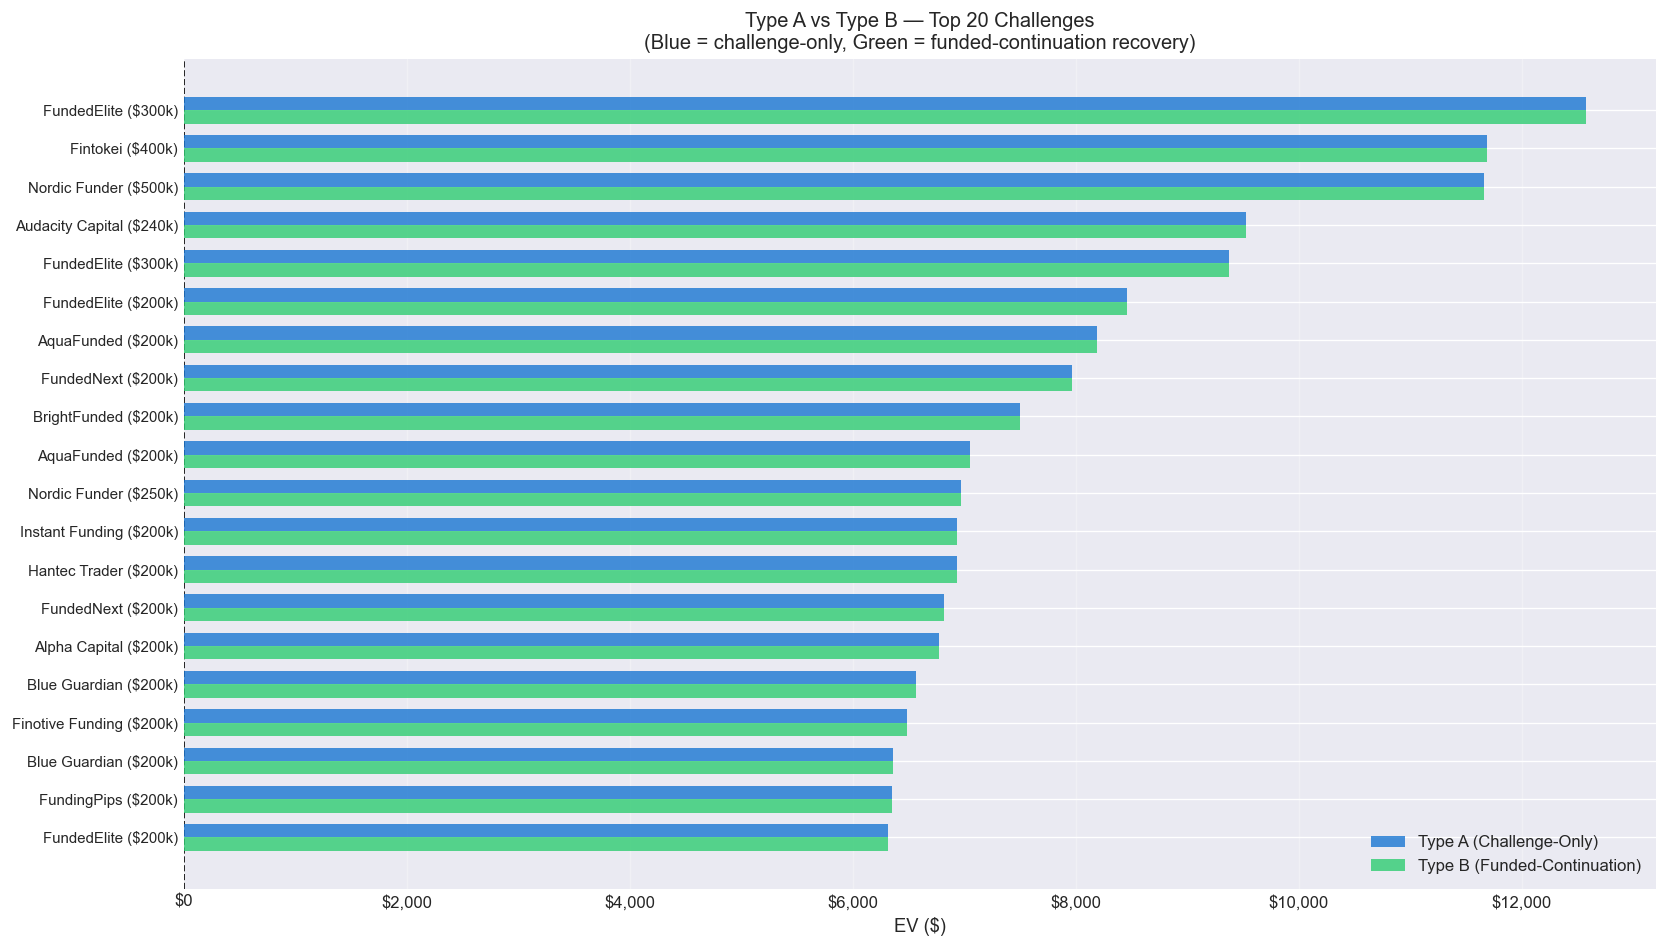

In [5]:
top20 = df_b.nlargest(20, "ev_b").sort_values("ev_b", ascending=True).copy()
top20["label"] = top20.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k)", axis=1
)

fig, ax = plt.subplots(figsize=(14, 8))
y = np.arange(len(top20))
h = 0.35

ax.barh(y + h/2, top20["type_a_ev"], h, label="Type A (Challenge-Only)",
        color="#1976d2", alpha=0.8, zorder=3)
ax.barh(y - h/2, top20["ev_b"], h, label="Type B (Funded-Continuation)",
        color="#2ecc71", alpha=0.8, zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(top20["label"], fontsize=9)
ax.axvline(x=0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("EV ($)", fontsize=11)
ax.set_title("Type A vs Type B — Top 20 Challenges\n"
             "(Blue = challenge-only, Green = funded-continuation recovery)", fontsize=12)
ax.legend(fontsize=10, loc="lower right")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5 — Funded Phase Walkthrough (Single Challenge)

Detailed cycle-by-cycle view of how the insured stack, withdrawals, and drag evolve.

In [6]:
# Pick the best Type B challenge
best_idx = df_b["ev_b"].idxmax()
best = results_b[best_idx]

print(f"Challenge: {best['firm']} — ${best['account_size']:,}")
print(f"Challenge cost (Type A): ${best['challenge_cost']:,.2f}")
print(f"Type A EV: ${best['type_a_ev']:,.2f}")
print(f"Type B EV: ${best['ev_b']:,.2f}")
print(f"Advantage: ${best['ev_advantage']:+,.2f}")
print()

df_cycles = pd.DataFrame(best["cycles"])
df_cycles.style.format({
    "prob_alive": "{:.1%}",
    "insured_stack": "${:,.2f}",
    "withdrawal": "${:,.2f}",
    "exp_withdrawal": "${:,.2f}",
    "drag": "${:,.2f}",
    "exp_drag": "${:,.2f}",
    "prob_fail": "{:.1%}",
    "exp_recovery": "${:,.2f}",
    "hedge_size_funded": "${:,.0f}",
    "capital_funded": "${:,.0f}",
}).set_caption(f"Type B Cycle Detail — {best['firm']} ${best['account_size']:,}")

Challenge: FundedElite — $300,000
Challenge cost (Type A): $6,626.30
Type A EV: $12,573.70
Type B EV: $12,573.70
Advantage: $+0.00



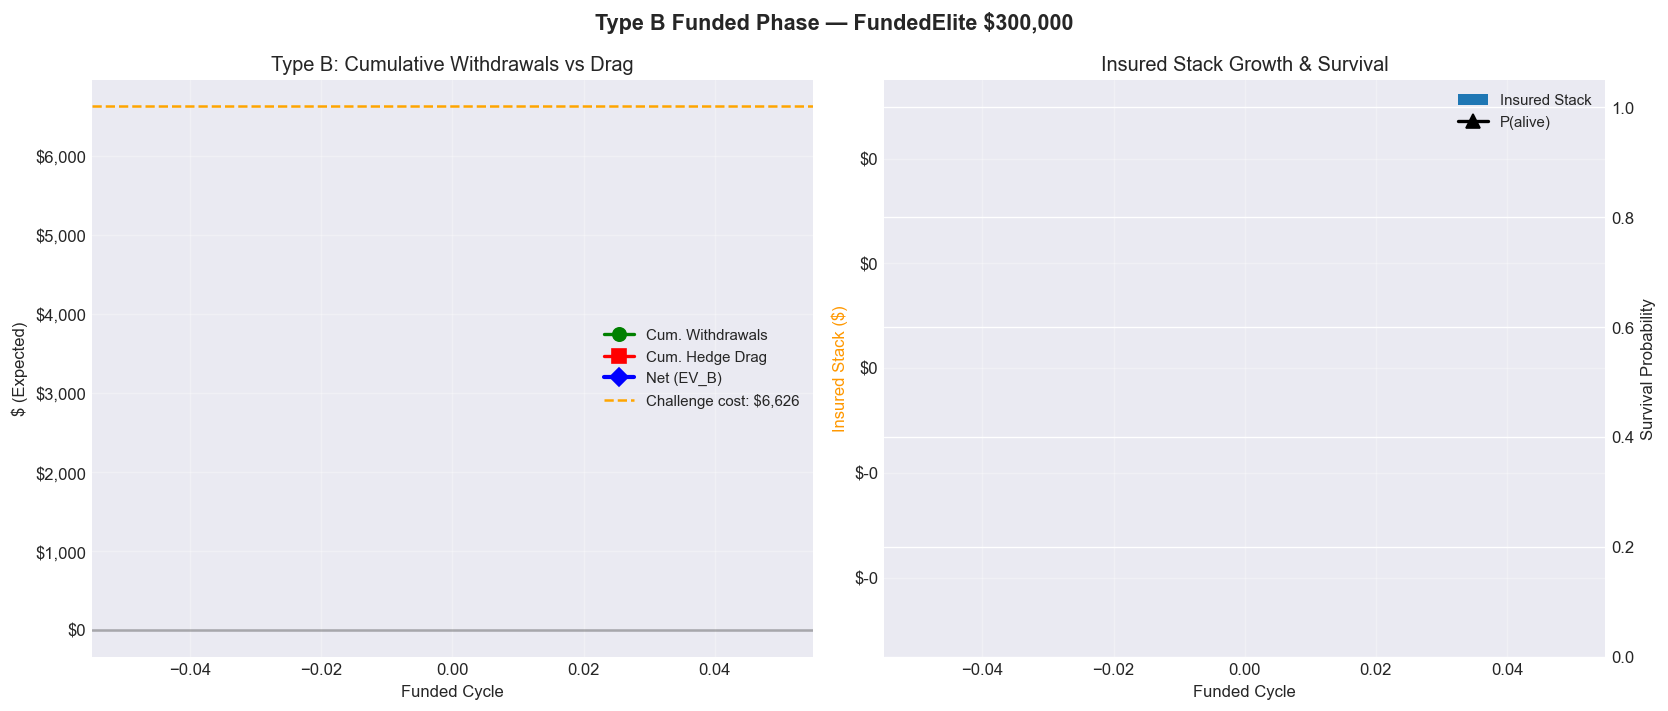

In [7]:
# Visualise the funded phase
cycles = best["cycles"]
cyc_nums = [c["cycle"] for c in cycles]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: cumulative withdrawals vs cumulative drag
cum_w = np.cumsum([c["exp_withdrawal"] for c in cycles])
cum_d = np.cumsum([c["exp_drag"] for c in cycles])
cum_net = cum_w - cum_d

ax1.plot(cyc_nums, cum_w, 'g-o', linewidth=2, markersize=8, label="Cum. Withdrawals")
ax1.plot(cyc_nums, cum_d, 'r-s', linewidth=2, markersize=8, label="Cum. Hedge Drag")
ax1.plot(cyc_nums, cum_net, 'b-D', linewidth=2.5, markersize=8, label="Net (EV_B)")
ax1.axhline(y=best["challenge_cost"], color="orange", linestyle="--", linewidth=1.5,
            label=f"Challenge cost: ${best['challenge_cost']:,.0f}")
ax1.axhline(y=0, color="black", linestyle="-", alpha=0.3)

ax1.set_xlabel("Funded Cycle")
ax1.set_ylabel("$ (Expected)")
ax1.set_title("Type B: Cumulative Withdrawals vs Drag")
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

# Right: insured stack growth and survival probability
stacks = [c["insured_stack"] for c in cycles]
probs = [c["prob_alive"] for c in cycles]

ax2_twin = ax2.twinx()
ax2.bar(cyc_nums, stacks, alpha=0.6, color="#ff9800", label="Insured Stack", zorder=3)
ax2_twin.plot(cyc_nums, probs, 'k-^', linewidth=2, markersize=8, label="P(alive)")

ax2.set_xlabel("Funded Cycle")
ax2.set_ylabel("Insured Stack ($)", color="#ff9800")
ax2_twin.set_ylabel("Survival Probability")
ax2.set_title("Insured Stack Growth & Survival")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2_twin.set_ylim(0, 1.05)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle(f"Type B Funded Phase — {best['firm']} ${best['account_size']:,}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 — Survival Rate Sensitivity

How does the funded account's survival probability affect Type B EV?

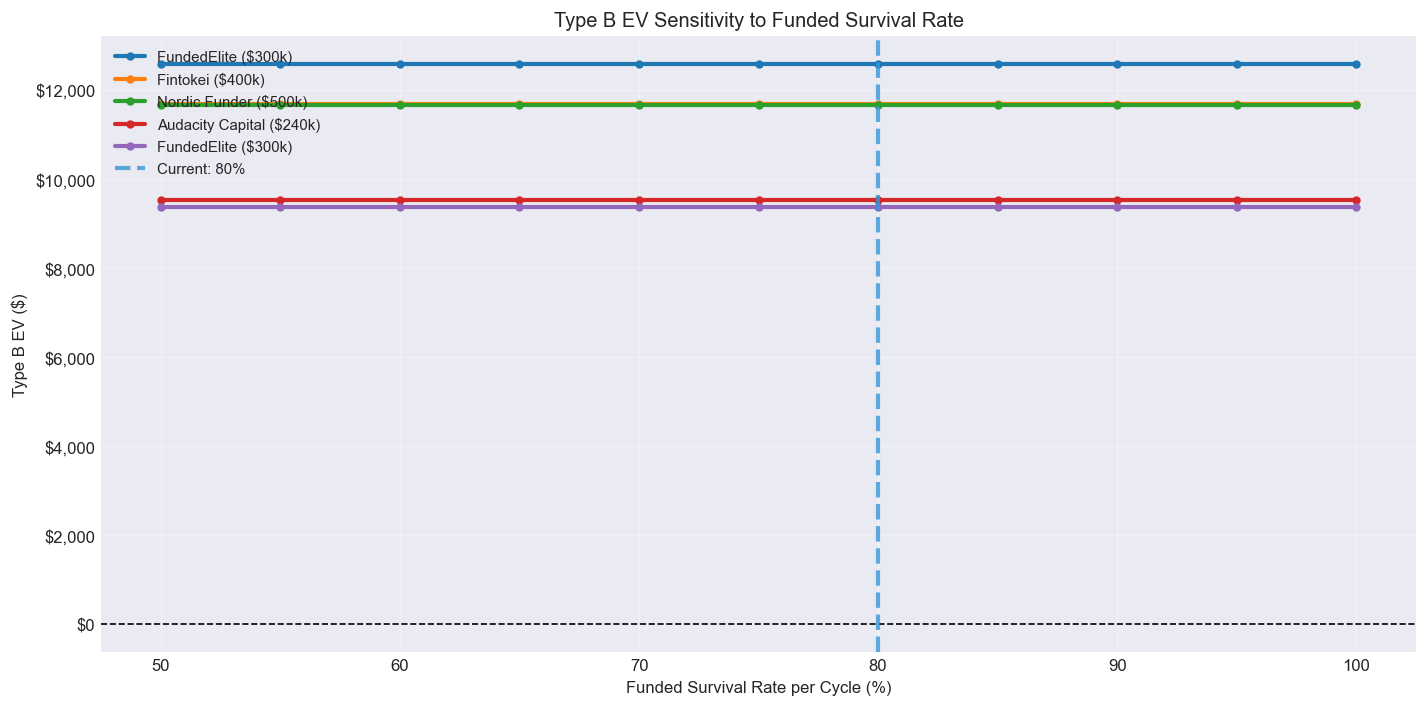

In [8]:
# Pick top 5 challenges
top5_idx = df_b.nlargest(5, "ev_b").index.tolist()
top5_challenges = [challenges[i] for i in top5_idx]

survival_sweep = np.arange(0.50, 1.01, 0.05)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors

for i, ch in enumerate(top5_challenges):
    evs = [compute_type_b(ch, survival_rate=sr)["ev_b"] for sr in survival_sweep]
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"
    ax.plot(survival_sweep * 100, evs, marker='o', markersize=4,
            label=label, linewidth=2.5, color=colors[i % 10])

ax.axhline(y=0, color="black", linewidth=1, linestyle="--")
ax.axvline(x=FUNDED_SURVIVAL_RATE * 100, color="#3498db", linewidth=2.5,
           linestyle="--", alpha=0.8, label=f"Current: {FUNDED_SURVIVAL_RATE*100:.0f}%")

ax.set_xlabel("Funded Survival Rate per Cycle (%)")
ax.set_ylabel("Type B EV ($)")
ax.set_title("Type B EV Sensitivity to Funded Survival Rate")
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7 — EV Advantage Distribution (Type B − Type A)

How much does continuing to hedge at funded actually add?

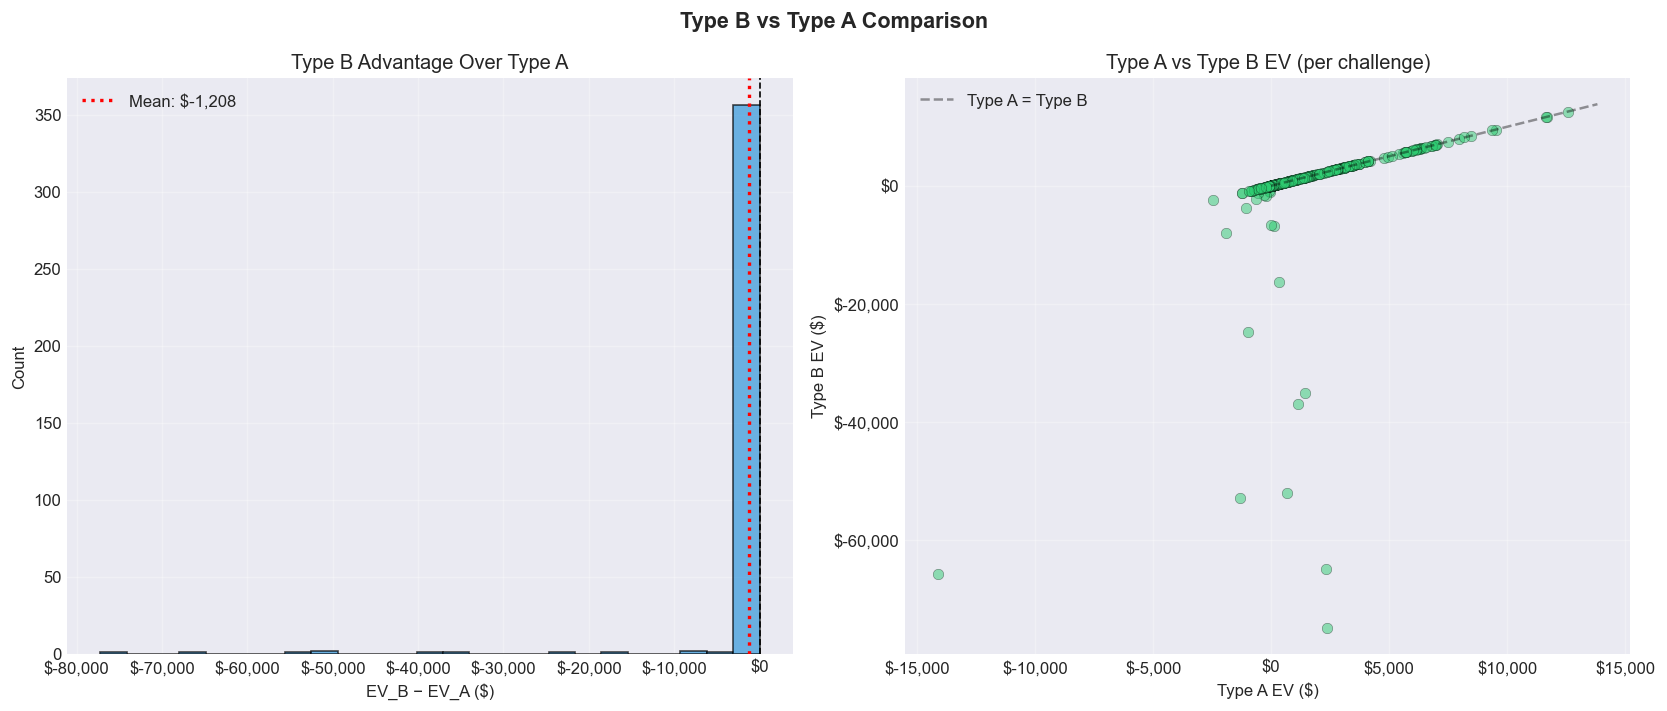


Type B beats Type A in 0/368 challenges
Average advantage: $-1,208.40


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: histogram of EV advantage
ax1.hist(df_b["ev_advantage"], bins=25, color="#3498db", alpha=0.7, edgecolor="black")
ax1.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax1.axvline(x=df_b["ev_advantage"].mean(), color="red", linestyle=":", linewidth=2,
            label=f"Mean: ${df_b['ev_advantage'].mean():,.0f}")
ax1.set_xlabel("EV_B − EV_A ($)")
ax1.set_ylabel("Count")
ax1.set_title("Type B Advantage Over Type A")
ax1.legend()
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

# Right: scatter Type A EV vs Type B EV
ax2.scatter(df_b["type_a_ev"], df_b["ev_b"], alpha=0.5, c="#2ecc71",
            edgecolors="black", linewidth=0.3, s=40)
lim = max(df_b["type_a_ev"].max(), df_b["ev_b"].max()) * 1.1
ax2.plot([0, lim], [0, lim], 'k--', alpha=0.4, label="Type A = Type B")
ax2.set_xlabel("Type A EV ($)")
ax2.set_ylabel("Type B EV ($)")
ax2.set_title("Type A vs Type B EV (per challenge)")
ax2.legend()
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)

plt.suptitle("Type B vs Type A Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

better = (df_b["ev_advantage"] > 0).sum()
print(f"\nType B beats Type A in {better}/{len(df_b)} challenges")
print(f"Average advantage: ${df_b['ev_advantage'].mean():,.2f}")

## 8 — Type B Summary

### What Type B tells you

**For static DD (cross-firm pair):**
- Type B is the same as Type A for static DD — payouts extracted from paired funded accounts at DIFFERENT firms
- No personal hedge drag, no recovery mechanism needed
- Cost = 2 x challenge fee + hedge losses (one at each prop firm)
- Revenue limited by floor(DD / target) payouts per pair

**For trailing DD (personal hedge):**
- Challenge costs are recoverable — the funded hedge carries the cost stack
- The hedge continues through funded, compounding costs further
- If funded fails → hedge recovers the FULL cost stack (challenge + funded drag)
- EV_B = expected funded withdrawals - expected hedge drag

### Key insight

For trailing DD, the funded-phase compounding is real and material.
The insured stack grows through funded, making the hedge bigger and the drag costlier.
But on failure, the entire accumulated stack is recoverable.

### Limitations

- Trailing DD funded drag scales with the cost stack (bigger stack = bigger drag)
- Capital requirement grows as the hedge gets larger at funded
- Failure only **recovers** costs — it doesn't produce surplus profit

> For surplus on failure, see **Type C** notebook.